# CINL Prisma QA

## Introduction

This notebook contains code to calculate images and metrics that can be used for quality assurance of MRI data generated on the Siemens MAGNETOM Prisma at CINL.

Currently, the notebook supports the following protocols:
- fMRI stability using fBIRN phantom

The following protocols will be implemented in the future:
- RF noise
- DWI
- MRS
- coil specific protocols

## Prerequisites

The conda environment for these scripts can be loaded from `environment.yml`, which contains all the required python packages.


/var/folders/v_/33wg3kzn5q54tpczjxxwwzdh0000gn/T/ipykernel_86300/2237427372.py:84: RuntimeWarning: invalid value encountered in divide
  sfnr_img = signal_img / fluctuation_noise_img


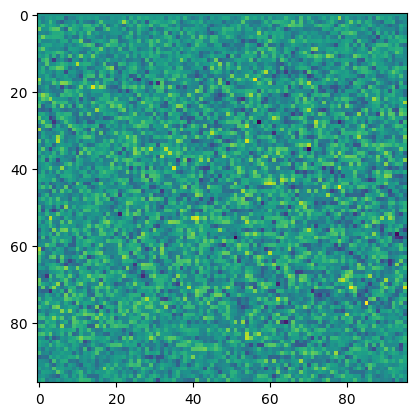

210.0750624055228


" plt.plot(time_points, averages, 'o', label='Average measured ROI signal')\nplt.plot(t_fit, y_fit, '-', label=f'Polynomial fit (Degree {degree})')\nplt.title('Polynomial fit to Average ROI signal')\nplt.xlabel('Volume')\nplt.ylabel('Average ROI signal')\nplt.legend()\nplt.show()\n\nplt.plot(time_points, residuals, 'o', label='Detrended ROI signal')\nplt.title('Detrended average ROI signal')\nplt.xlabel('Volume')\nplt.ylabel('Average ROI signal (detrended)')\nplt.legend()\nplt.show() "

In [2]:
import nibabel as nib
import nilearn as nil
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import numpy as np
import os

# load proxy images
fates = nib.load('../sub-fbirn/ses-Qa02232024CINL7043/func/sub-fbirn_ses-Qa02232024CINL7043_task-stab_bold.nii.gz')
# request array data from proxy images
fates_data = fates.get_fdata()

# view header
# fates_header = fates.header
# print(fates_header)

# get the size of each dimension in the data array
x_dim, y_dim, z_dim, t_dim = fates_data.shape

# region of interest
roi_x, roi_y, roi_z = 49, 63, 23
roi_size = 20
half_size = roi_size // 2

# coordinate of center slice is roi_z

# define the bounds of the region of interest and ensure they stay within the image bounds
x_min = max(roi_x - half_size, 0)
x_max = min(roi_x + half_size, x_dim - 1)
y_min = max(roi_y - half_size, 0)
y_max = min(roi_y + half_size, y_dim - 1)
# z_min = max(roi_z - half_size, 0)
# z_max = min(roi_z + half_size, z_dim - 1)

# calculate signal image (simple average)
# take center slice only
signal_img = np.mean(fates_data[:,:,roi_z,:], axis=2)

# calculate temporal fluctuation noise image
# center slice only
# Initialize an array to store the standard deviation of residuals
fluctuation_noise_img = np.zeros((x_dim, y_dim))

# Loop through each voxel
for i in range(x_dim):
    for j in range(y_dim):
            # Extract the time-series for the current voxel
            time_series = fates_data[i, j, roi_z, :]

            # Fit a second-order polynomial
            time_points = np.arange(t_dim)
            coefficients = np.polyfit(time_points, time_series, 2)
            polynomial = np.poly1d(coefficients)

            # Calculate the residuals (original - fitted)
            fitted_values = polynomial(time_points)
            residuals = time_series - fitted_values

            # Calculate the standard deviation of the residuals
            fluctuation_noise_img[i, j] = np.std(residuals)

# TODO vectorize code for timely 3d calculation
""" # prepare time points (0, 1, ... , T-1)
time_points = np.arange(t_dim)
# generate design matrix for 2nd-order polynomial
# columns for powers x^2, x^1, x^0
X = np.vstack([time_points**2, time_points, np.ones(t_dim)]).T
# reshape data for batch processing
data_transposed = np.transpose(fates_data, (3, 0, 1, 2))
data_reshaped = np.reshape(fates_data, (t_dim, -1))
# perform least squares fit
coefficients, _, _, _ = np.linalg.lstsq(X, data_reshaped, rcond=None)
# calculate fitted values from coefficients
fitted_values = X @ coefficients
# compute residuals
residuals = data_reshaped - fitted_values
# calculate standard deviation of residuals along time axis
residuals_std = np.std(residuals, axis=0)
# reshape to original spatial dimensions
fluct_noise_img = np.reshape(residuals_std, (x_dim, y_dim, z_dim)) """

# SIGNAL-TO-FLUCTUATION-NOISE RATIO (SFNR) IMAGE
# voxelwise division of signal and temporal fluctuation noise image
sfnr_img = signal_img / fluctuation_noise_img
# summary SFNR value from ROI
sfnr = np.mean(sfnr_img[x_min:x_max, y_min:y_max])

# STATIC SPATIAL NOISE IMAGE

sumEven_img = np.sum(fates_data[:, :, roi_z, 0:2:t_dim], axis=2)
sumOdd_img = np.sum(fates_data[:, :, roi_z, 1:2:t_dim], axis=2)
diff_img = sumOdd_img - sumEven_img

# PERCENT FLUCTUATION AND DRIFT
# initialize array to store average roi values
averages = np.zeros(fates_data.shape[3])

# compute average of each time point
for t in range(fates_data.shape[3]):
    region = fates_data[x_min:x_max+1, y_min:y_max+1, roi_z, t]
    averages[t] = np.mean(region)

# fit polynomal for detrending
time_points = np.arange(len(averages))
degree = 2
coefficients = np.polyfit(time_points, averages, degree)
p = np.poly1d(coefficients)

# evaluate polynomial over time range
t_fit = np.linspace(time_points.min(), time_points.max(), 160)
y_fit = p(t_fit)

# calculate residuals (detrended data)
residuals = averages - y_fit

# PLOTS
plt.imshow(diff_img)
plt.show()

# PRINT VALUES
print(sfnr)

""" plt.plot(time_points, averages, 'o', label='Average measured ROI signal')
plt.plot(t_fit, y_fit, '-', label=f'Polynomial fit (Degree {degree})')
plt.title('Polynomial fit to Average ROI signal')
plt.xlabel('Volume')
plt.ylabel('Average ROI signal')
plt.legend()
plt.show()

plt.plot(time_points, residuals, 'o', label='Detrended ROI signal')
plt.title('Detrended average ROI signal')
plt.xlabel('Volume')
plt.ylabel('Average ROI signal (detrended)')
plt.legend()
plt.show() """

# visualize raw data
# nib.viewers.OrthoSlicer3D(fates_data).show()

# region of interest
# center of sphere is ~ 63, 49, 23
# check
# intensity = fates_data[49,63,23,0]
# print(intensity)

# plt.imshow(fates_data[:,:,23,0])
# plt.show()